# KNN
O código abaixo carrega o dataset MNIST, que consiste em imagens de dígitos entre $0$ e $9$ e carrego a classe com o algoritmo do KNN

In [14]:
from dataclasses import dataclass

from typing import Callable, Any
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

root = Path().resolve().parent  # aponta para machine-learning/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from classes.knn import KNN


SEED = 42
np.random.seed(SEED)

@dataclass
class Dataset:
    features_train: np.ndarray 
    features_test: np.ndarray  
    labels_train: np.ndarray   
    labels_test: np.ndarray

# Import dataset and separate train/test subsets
mnist = Dataset(*train_test_split(
    *load_digits(return_X_y=True),
    random_state=SEED,
))

Agora eu faço uma procura pela melhor quantidade de amostras para considerar durante o treion ($k$)

In [15]:
ks = np.linspace(3, 13, 10, dtype=int)

predictions = np.zeros((len(ks), len(mnist.labels_test)))

for idx, k in enumerate(ks):
    knn = KNN(
        k=k,
        distance_function=lambda x, y: np.linalg.norm(x - y),
        X=mnist.features_train,
        t=mnist.labels_train
    )
    k_predictions = np.zeros_like(mnist.labels_test)
    for i, test_point in enumerate(mnist.features_test):
        k_predictions[i] = knn(test_point)
    predictions[idx] = k_predictions

Agora vou calcular a precisão das predições e selecionar o melhor $k$ (Há outras métricas interessantes também, mas manterei simples)

In [16]:
accuracies = np.zeros((len(ks),))
for idx, k in enumerate(ks):
    correct_predictions = np.sum(predictions[idx] == mnist.labels_test)
    accuracies[idx] = correct_predictions / len(mnist.labels_test)

In [17]:
print("KNN Accuracies:")
for idx, k in enumerate(ks):
    print(f"K={k}: {accuracies[idx]:.4f}")

KNN Accuracies:
K=3: 0.9867
K=4: 0.9867
K=5: 0.9933
K=6: 0.9956
K=7: 0.9933
K=8: 0.9889
K=9: 0.9867
K=10: 0.9867
K=11: 0.9800
K=13: 0.9800


Agora, para uma visualização interessante, mostramos as amostras que foram classificadas incorretamente

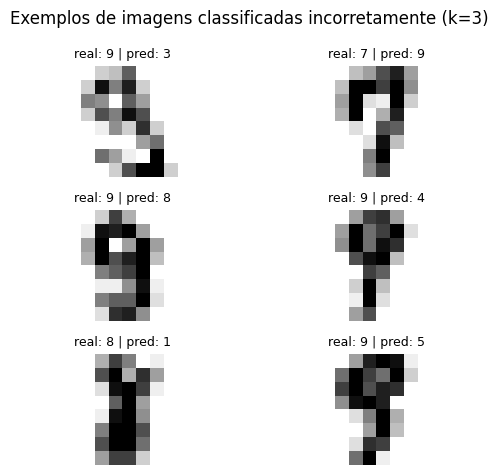

In [18]:
# Amostras classificadas incorretamente:
missclassified_indices = np.where(predictions[0] != mnist.labels_test)[0]

missclassified_samples = mnist.features_test[missclassified_indices]
missclassified_labels = mnist.labels_test[missclassified_indices]


# Exibir algumas amostras classificadas incorretamente
n_to_show = min(16, len(missclassified_indices))
fig, axes = plt.subplots(3, 2)
axes = axes.ravel()

for i in range(n_to_show):
    idx_test = missclassified_indices[i]
    axes[i].imshow(mnist.features_test[idx_test].reshape(8, 8), cmap="gray_r")
    axes[i].set_title(
        f"real: {mnist.labels_test[idx_test]} | pred: {int(predictions[0][idx_test])}",
        fontsize=9
    )
    axes[i].axis("off")

# Desligar os eixos dos subplots restantes
for i in range(n_to_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Exemplos de imagens classificadas incorretamente (k=3)")
plt.tight_layout()
plt.show()

E até que da pra entender o porquê o algoritmo classifica elas errado, elas estão muito "mal escritas" vamos dizer assim, lembrando bastante outros números